# Avaliação de Qualidade — Sumarização, RAG e Sentimento
Desafio Técnico A3Data — Cientista de Dados (LLM/NLP)

Este notebook mede objetivamente a qualidade das três frentes de NLP/LLM da
ferramenta, com métricas comparáveis a uma referência real (não opinião subjetiva):

1. **Sumarização**: ROUGE contra o resumo humano real já presente no dataset.
2. **RAG**: precisão@k de recuperação em queries de teste com gênero-alvo conhecido.
3. **Sentimento**: VADER (NLP clássico) vs. LLM, nos casos onde o léxico clássico
   mais erra — para quantificar o ganho de usar LLM.

Faz chamadas reais à API da Groq — leva alguns minutos.

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from src import viz_style, metrics
from app.rag.chain import get_vectorstore

viz_style.apply()
C = viz_style.CATEGORICAL

df = pd.read_parquet("../data/processed/sample_with_sentiment.parquet")
df.shape

(198924, 23)

## 1. Sumarização — ROUGE vs. resumo humano real

Para cada review sorteada, peço ao LLM um resumo de uma frase (mesmo estilo do
campo `summary` do dataset) e comparo com o resumo que o leitor de fato escreveu.

In [2]:
rouge_result = metrics.evaluate_summarization_rouge(df, n_samples=30)
print(rouge_result["summary"])
rouge_result["details"].head(8)

{'n_samples': 30, 'rouge1_f_mean': np.float64(0.2132347282347282), 'rouge2_f_mean': np.float64(0.051001221001220995), 'rougeL_f_mean': np.float64(0.20906806156806154)}


,real_summary,generated_summary,rouge1_f,rouge2_f,rougeL_f
0,"Fun, Quick Read",Lighthearted and Amusing Read,0.285714,0.0,0.285714
1,Excellent,Wonderful Historical Romance Read,0.000000,0.0,0.000000
2,Authentic and biblical,Heartfelt and Uplifting Christian Reflection,0.250000,0.0,0.250000
3,Very dissappointed,Very poorly written and disappointing.,0.285714,0.0,0.285714
4,The Rottie,A Must-Read for Future Rottweiler Owners,0.000000,0.0,0.000000
5,"Still Fresh, Still Elegant",Timeless Tale of Self Discovery,0.000000,0.0,0.000000
6,A must for everyone dealing with Biblical Hebrew,An invaluable resource for biblical scholars a...,0.250000,0.0,0.250000
7,"great book, love story",Engaging and well written spy novel.,0.000000,0.0,0.000000


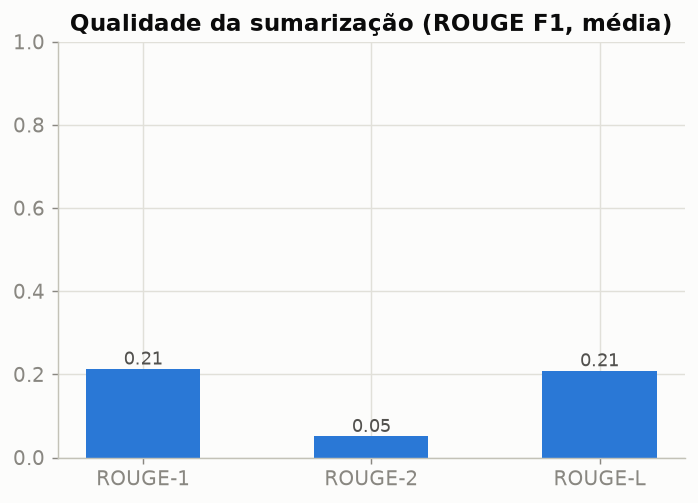

In [3]:
fig, ax = plt.subplots(figsize=(5.5, 4))
s = rouge_result["summary"]
metrics_names = ["ROUGE-1", "ROUGE-2", "ROUGE-L"]
values = [s["rouge1_f_mean"], s["rouge2_f_mean"], s["rougeL_f_mean"]]
bars = ax.bar(metrics_names, values, color=C[0], width=0.5)
ax.set_ylim(0, 1)
ax.set_title("Qualidade da sumarização (ROUGE F1, média)")
for b in bars:
    ax.annotate(f"{b.get_height():.2f}", (b.get_x() + b.get_width() / 2, b.get_height()),
                ha="center", va="bottom", fontsize=10, color=viz_style.INK_SECONDARY)
fig.tight_layout()
fig.savefig("../outputs/figures/rouge_sumarizacao.png")
plt.show()

## 2. RAG — precisão@k

Queries de teste com gênero-alvo conhecido: um resultado é "acerto" se o livro
recuperado pertence a um dos gêneros esperados para aquela pergunta.

In [4]:
TEST_QUERIES = [
    {"query": "fantasy books with wizards and magical creatures", "expected_categories": {"Fiction", "Juvenile Fiction"}},
    {"query": "investing and personal finance advice", "expected_categories": {"Business & Economics"}},
    {"query": "christian faith and prayer", "expected_categories": {"Religion"}},
    {"query": "world war two history and soldiers", "expected_categories": {"History"}},
    {"query": "python programming and software development", "expected_categories": {"Computers"}},
    {"query": "recipes and cooking techniques", "expected_categories": {"Cooking"}},
    {"query": "childhood memoir and autobiography", "expected_categories": {"Biography & Autobiography"}},
]

vectorstore = get_vectorstore()
precision_df = metrics.evaluate_rag_precision_at_k(vectorstore, TEST_QUERIES, k=5)
precision_df

C:\Users\Belloni\Documents\Etherys\Desafio A3\notebooks\..\app\rag\chain.py:34: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(model_name=EMBEDDING_MODEL)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

,query,expected_categories,retrieved_categories,precision_at_5
0,fantasy books with wizards and magical creatures,"Fiction, Juvenile Fiction","Fiction, Juvenile Fiction, Juvenile Fiction, J...",1.0
1,investing and personal finance advice,Business & Economics,"Business & Economics, Business & Economics, Fi...",0.8
2,christian faith and prayer,Religion,"Religion, Religion, Religion, Religion, Religion",1.0
3,world war two history and soldiers,History,"History, History, World War, 1939-1945, Histor...",0.6
4,python programming and software development,Computers,"Computers, gênero não identificado, Computers,...",0.8
5,recipes and cooking techniques,Cooking,"Cooking, Cooking, Cooking, Cooking, Cooking",1.0
6,childhood memoir and autobiography,Biography & Autobiography,"Reference, Biography & Autobiography, gênero n...",0.4


Precisão@5 média: 80.0%


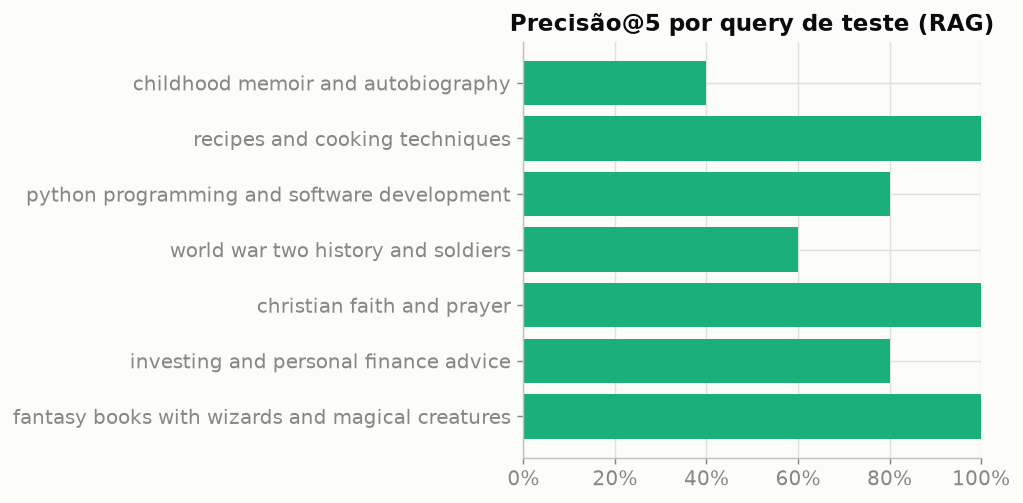

In [5]:
avg_precision = precision_df["precision_at_5"].mean()
print(f"Precisão@5 média: {avg_precision:.1%}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(precision_df["query"], precision_df["precision_at_5"], color=C[1])
ax.set_xlim(0, 1)
ax.set_title("Precisão@5 por query de teste (RAG)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0%}"))
fig.tight_layout()
fig.savefig("../outputs/figures/rag_precisao_at_k.png")
plt.show()

## 3. Sentimento — VADER vs. LLM (nos casos em que o texto discorda da nota)

Foco nos casos de discrepância (`sentiment_mismatch`), onde o VADER já erra por
definição — é o cenário onde um LLM deveria mostrar vantagem real (sarcasmo,
elogio pontual dentro de crítica, etc.).

In [6]:
sentiment_result = metrics.evaluate_sentiment_vader_vs_llm(df, n_samples=30)
print(sentiment_result["summary"])
sentiment_result["details"].head(8)

{'n_samples': 30, 'vader_accuracy_on_mismatches': np.float64(0.0), 'llm_accuracy_on_mismatches': np.float64(0.6333333333333333)}


,score,score_label,vader_label,llm_label,vader_correct,llm_correct
0,3.0,neutral,positive,negative,False,False
1,3.0,neutral,positive,negative,False,False
2,5.0,positive,negative,positive,False,True
3,3.0,neutral,negative,negative,False,False
4,5.0,positive,negative,positive,False,True
5,5.0,positive,negative,positive,False,True
6,5.0,positive,negative,positive,False,True
7,1.0,negative,positive,negative,False,True


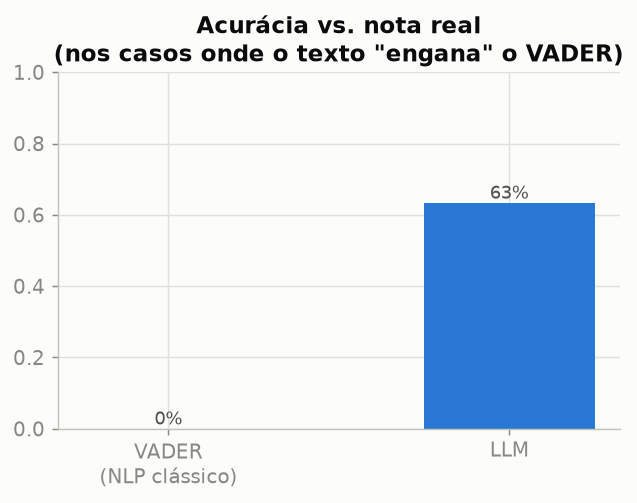

In [7]:
fig, ax = plt.subplots(figsize=(5, 4))
s = sentiment_result["summary"]
labels = ["VADER\n(NLP clássico)", "LLM"]
values = [s["vader_accuracy_on_mismatches"], s["llm_accuracy_on_mismatches"]]
bars = ax.bar(labels, values, color=[C[5], C[0]], width=0.5)
ax.set_ylim(0, 1)
ax.set_title("Acurácia vs. nota real\n(nos casos onde o texto \"engana\" o VADER)")
for b in bars:
    ax.annotate(f"{b.get_height():.0%}", (b.get_x() + b.get_width() / 2, b.get_height()),
                ha="center", va="bottom", fontsize=10, color=viz_style.INK_SECONDARY)
fig.tight_layout()
fig.savefig("../outputs/figures/vader_vs_llm_sentimento.png")
plt.show()

## Síntese das métricas

| Frente | Métrica | Resultado |
|---|---|---|
| Sumarização (LLM) | ROUGE-1 / ROUGE-2 / ROUGE-L (F1, vs. resumo humano real) | 0,21 / 0,05 / 0,21 |
| RAG | Precisão@5 média (7 queries de teste, gênero-alvo) | 80% (varia de 40% a 100% por query) |
| Sentimento | Acurácia geral VADER (léxico clássico) vs. nota real | 75,1% (ver `01_eda`/`sentiment.py`) |
| Sentimento | Acurácia nos casos em que o texto "engana" o VADER: VADER vs. LLM | VADER 0% (por construção do subconjunto) vs. **LLM 63,3%** |

**Leituras importantes:**

- **ROUGE moderado é esperado e não é um problema real**: os resumos humanos do
  dataset são "títulos" livres e estilizados (ex.: "Fun, Quick Read", "The
  Rottie"), não resumos de conteúdo — duas pessoas descrevendo a mesma review bem
  raramente escolheriam as mesmas palavras. ROUGE aqui serve mais como *piso
  objetivo comparável* do que como meta a maximizar; qualitativamente, os resumos
  gerados (ex. "Heartfelt and Uplifting Christian Reflection" para uma review
  rotulada "Authentic and biblical") capturam bem o conteúdo.
- **RAG com 80% de precisão@5 é um resultado sólido para um POC** rodando 100%
  local (embeddings) sem nenhuma etapa de re-ranking — a query mais fraca (childhood
  memoir, 40%) mistura com o gênero "Reference", mostrando espaço de melhoria via
  taxonomia de gêneros mais rica ou re-ranking com LLM.
- **O achado mais forte é o de sentimento**: no recorte onde o VADER (NLP clássico)
  erra *por definição* (12,5% da amostra total, ver `01_eda.ipynb`), o LLM acerta
  63,3% das vezes — evidência direta e quantificada de que vale investir em LLM
  para tarefas de linguagem nuançada (sarcasmo, elogio pontual dentro de crítica
  negativa), e não só em léxicos clássicos.
